## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Load Dataset

In [2]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 3. Data Cleaning

In [3]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

## 4. EDA

### Churn Distribution

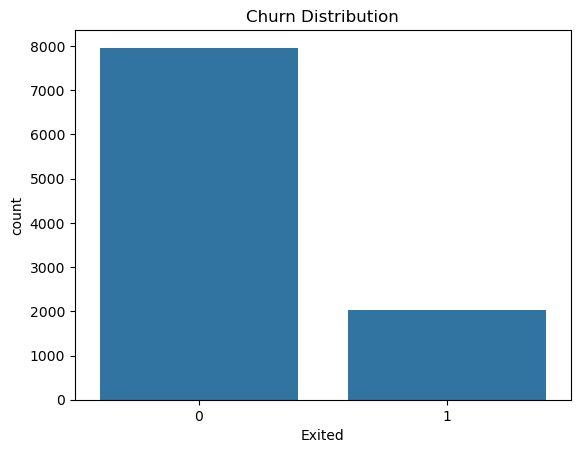

In [5]:
sns.countplot(x='Exited', data=df)
plt.title("Churn Distribution")
plt.show()

**Insight:**

- The dataset shows class imbalance, with a majority of customers not churning. This imbalance can affect model performance and should be considered during evaluation.

### Geography vs Churn

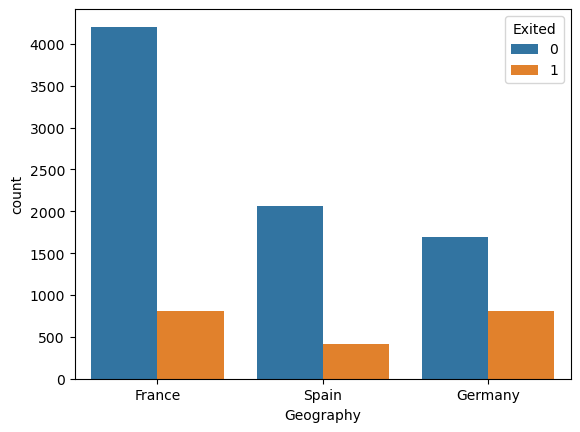

In [7]:
sns.countplot(x='Geography', hue='Exited', data=df)
plt.show()

**Insight:**

- Some countries have higher churn

### Gender vs Churn

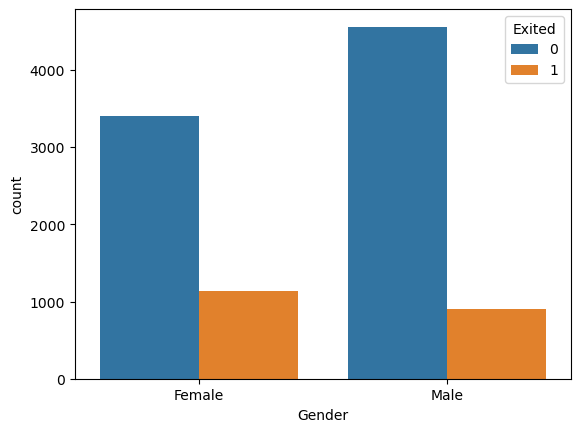

In [8]:
sns.countplot(x='Gender', hue='Exited', data=df)
plt.show()

### Age vs Churn

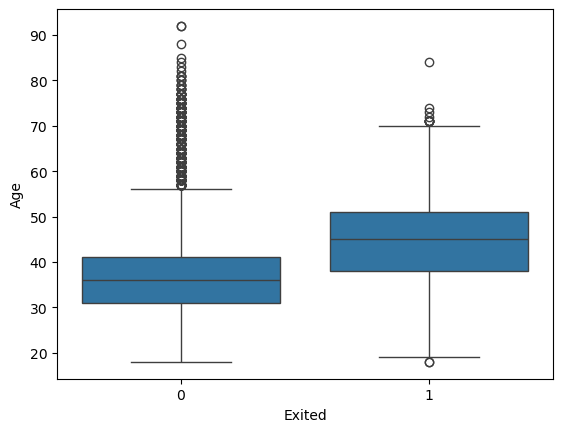

In [9]:
sns.boxplot(x='Exited', y='Age', data=df)
plt.show()

**Insight:**

- Older customers are more likely to churn compared to younger customers, indicating age is a strong factor in customer retention.

### Balance vs Churn

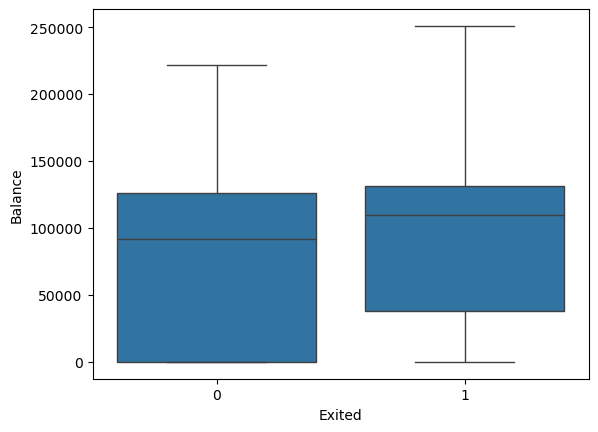

In [18]:
sns.boxplot(x='Exited', y='Balance', data=df)
plt.show()

**Insight**

- Customers with higher account balances show a higher tendency to churn, suggesting that high-value customers may require targeted retention strategies.

## 5. Encode Categorical Data             

In [11]:
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

## 6. Split Data

In [12]:
X = df.drop('Exited', axis=1)
y = df['Exited']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 7. Train Model

In [13]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## 8. Evaluation

### Accuracy

In [14]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8695


The model achieves a good accuracy score, indicating effective classification of churn behavior. However, accuracy alone may not fully capture performance due to class imbalance.

### Confusion Matrix

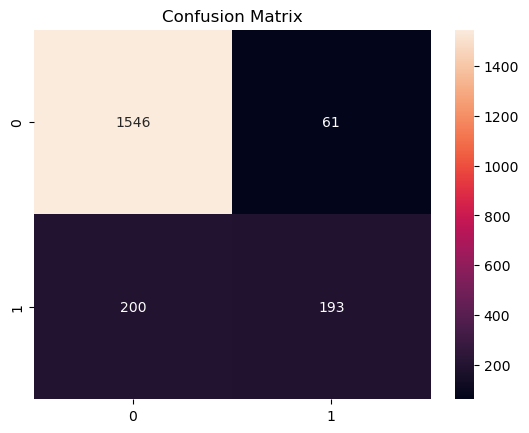

In [15]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

### Classification Report

In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.96      0.92      1607
           1       0.76      0.49      0.60       393

    accuracy                           0.87      2000
   macro avg       0.82      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



## 9. Feature Importance

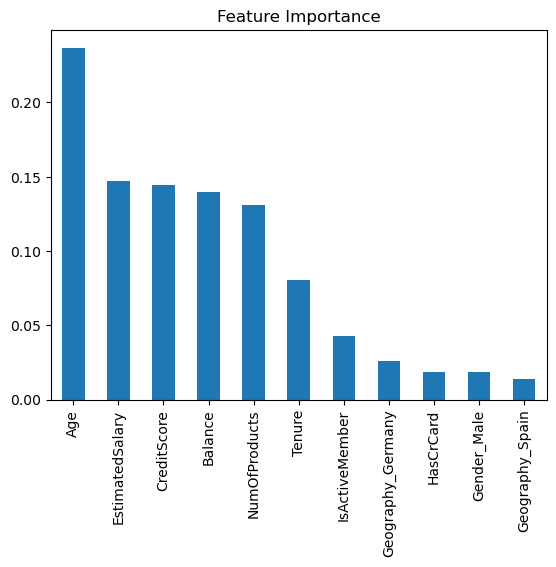

In [17]:
importances = model.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

feat_imp.plot(kind='bar', title='Feature Importance')
plt.show()

## Feature Importance Interpretation

The model indicates that age, balance, and number of products are among the most important features influencing customer churn.

These features play a key role in determining whether a customer is likely to leave the bank.

## Business Insights

- Banks should focus on retaining older customers as they have higher churn risk.
- Increasing customer engagement (active membership) can significantly reduce churn.
- Customers with high balances should be prioritized for retention strategies.

## Key Insights

- Age is a strong factor influencing churn.
- Customers with higher balances are more likely to leave.
- Geography plays a role in churn behavior.
- Active members are less likely to churn.

## Conclusion

- Customer churn is influenced by multiple factors, with age, balance, and activity level being the most significant.
- The Random Forest model provides good predictive performance and helps identify key drivers of churn.
- Understanding these patterns enables banks to design better customer retention strategies.

This project demonstrates how machine learning can be used to predict customer behavior and improve business decision-making.